In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8,6)

In [2]:
ROOT = Path.home() / "HDD/EventDatasets/EVIMO2_official"

SEQ = ROOT / \
"flea3_7/imo/train/scene10_dyn_train_00_000000"

print(SEQ)

/home/ayon/HDD/EventDatasets/EVIMO2_official/flea3_7/imo/train/scene10_dyn_train_00_000000


In [3]:
for f in sorted(SEQ.iterdir()):
    print(f.name)

dataset_classical.npz
dataset_depth.npz
dataset_events_p.npy
dataset_events_t.npy
dataset_events_xy.npy
dataset_info.npz
dataset_mask.npz


In [4]:
info = np.load(
    SEQ / "dataset_info.npz",
    allow_pickle=True
)

print(info.files)

['index', 'discretization', 'K', 'D', 'meta']


In [10]:
import numpy as np

# ============================================================
# Recursive Inspector
# ============================================================

def inspect(name, obj, level=0):

    indent = "    " * level

    print(f"\n{indent}{'='*80}")
    print(f"{indent}{name}")
    print(f"{indent}{'='*80}")

    # --------------------------------------------------------
    # NumPy Array
    # --------------------------------------------------------

    if isinstance(obj, np.ndarray):

        print(f"{indent}Type   : numpy.ndarray")
        print(f"{indent}Shape  : {obj.shape}")
        print(f"{indent}Dtype  : {obj.dtype}")
        print(f"{indent}Size   : {obj.size}")

        if obj.size == 0:
            print(f"{indent}<EMPTY ARRAY>")
            return

        # Scalar ndarray
        if obj.ndim == 0:
            inspect(name + ".item()", obj.item(), level + 1)
            return

        # Numeric arrays
        if np.issubdtype(obj.dtype, np.number):

            print(f"{indent}Min    : {obj.min()}")
            print(f"{indent}Max    : {obj.max()}")

        print(f"\n{indent}Preview")

        if obj.ndim == 1:
            print(obj[:10])

        elif obj.ndim == 2:
            print(obj[:5])

        elif obj.ndim == 3:
            print(obj[0])

        else:
            print(obj.flatten()[:10])

        return

    # --------------------------------------------------------
    # Dictionary
    # --------------------------------------------------------

    if isinstance(obj, dict):

        print(f"{indent}Python Type : dict")
        print(f"{indent}Keys        : {len(obj)}")

        print()

        for key in obj.keys():

            inspect(key, obj[key], level + 1)

        return

    # --------------------------------------------------------
    # List
    # --------------------------------------------------------

    if isinstance(obj, list):

        print(f"{indent}Python Type : list")
        print(f"{indent}Length      : {len(obj)}")

        for i, value in enumerate(obj[:5]):

            inspect(f"[{i}]", value, level + 1)

        return

    # --------------------------------------------------------
    # Tuple
    # --------------------------------------------------------

    if isinstance(obj, tuple):

        print(f"{indent}Python Type : tuple")
        print(f"{indent}Length      : {len(obj)}")

        for i, value in enumerate(obj):

            inspect(f"[{i}]", value, level + 1)

        return

    # --------------------------------------------------------
    # Structured array / record
    # --------------------------------------------------------

    if isinstance(obj, np.void):

        print(f"{indent}Structured Record")

        for field in obj.dtype.names:

            inspect(field, obj[field], level + 1)

        return

    # --------------------------------------------------------
    # Object with attributes
    # --------------------------------------------------------

    if hasattr(obj, "__dict__"):

        print(f"{indent}Python Object")
        print(f"{indent}{type(obj)}")

        inspect("__dict__", obj.__dict__, level + 1)

        return

    # --------------------------------------------------------
    # Scalar
    # --------------------------------------------------------

    print(f"{indent}Python Type : {type(obj)}")
    print(f"{indent}Value       : {obj}")


# ============================================================
# NPZ Inspector
# ============================================================

def inspect_npz(npz_file):

    print("="*100)
    print(npz_file)
    print("="*100)

    data = np.load(npz_file, allow_pickle=True)

    print("\nKeys Found\n")

    for key in data.files:
        print("  -", key)

    print()

    for key in data.files:

        inspect(key, data[key])

        print("\n\n")


# ============================================================
# Usage
# ============================================================

inspect_npz(
    SEQ / "dataset_info.npz"
)

/home/ayon/HDD/EventDatasets/EVIMO2_official/flea3_7/imo/train/scene10_dyn_train_00_000000/dataset_info.npz

Keys Found

  - index
  - discretization
  - K
  - D
  - meta


index
Type   : numpy.ndarray
Shape  : (0,)
Dtype  : float32
Size   : 0
<EMPTY ARRAY>




discretization
Type   : numpy.ndarray
Shape  : ()
Dtype  : float64
Size   : 1

    discretization.item()
    Python Type : <class 'float'>
    Value       : 0.01




K
Type   : numpy.ndarray
Shape  : (3, 3)
Dtype  : float64
Size   : 9
Min    : 0.0
Max    : 2065.159912

Preview
[[2.06515991e+03 0.00000000e+00 1.01194000e+03]
 [0.00000000e+00 2.06469995e+03 7.84062988e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]




D
Type   : numpy.ndarray
Shape  : (4,)
Dtype  : float64
Size   : 4
Min    : -0.105435
Max    : 0.042631

Preview
[-0.105435  0.042631  0.        0.      ]




meta
Type   : numpy.ndarray
Shape  : ()
Dtype  : object
Size   : 1

    meta.item()
    Python Type : dict
    Keys        : 4


        frames
        

In [16]:
from pathlib import Path

for f in SEQ.iterdir():
    print(f.name, f.stat().st_size / 1024 / 1024, "MB")

dataset_classical.npz 1523.603874206543 MB
dataset_depth.npz 68.16751098632812 MB
dataset_events_p.npy 0.0001220703125 MB
dataset_events_t.npy 0.0001220703125 MB
dataset_events_xy.npy 0.0001220703125 MB
dataset_info.npz 3.233414649963379 MB
dataset_mask.npz 5.459318161010742 MB


In [17]:
from pathlib import Path
import numpy as np

root = Path.home() / "HDD/EventDatasets/EVIMO2_official"

count = 0

for events in root.rglob("dataset_events_t.npy"):

    n = len(np.load(events, mmap_mode="r"))

    if n > 0:

        print(n, events)

        count += 1

        if count == 20:
            break

5512005 /home/ayon/HDD/EventDatasets/EVIMO2_official/left_camera/imo/eval/scene13_dyn_test_00_000000/dataset_events_t.npy
11909530 /home/ayon/HDD/EventDatasets/EVIMO2_official/left_camera/imo/eval/scene13_dyn_test_05_000000/dataset_events_t.npy
16578066 /home/ayon/HDD/EventDatasets/EVIMO2_official/left_camera/imo/eval/scene14_dyn_test_03_000000/dataset_events_t.npy
13308610 /home/ayon/HDD/EventDatasets/EVIMO2_official/left_camera/imo/eval/scene14_dyn_test_04_000000/dataset_events_t.npy
13174728 /home/ayon/HDD/EventDatasets/EVIMO2_official/left_camera/imo/eval/scene14_dyn_test_05_000000/dataset_events_t.npy
9715600 /home/ayon/HDD/EventDatasets/EVIMO2_official/left_camera/imo/eval/scene15_dyn_test_01_000000/dataset_events_t.npy
9739491 /home/ayon/HDD/EventDatasets/EVIMO2_official/left_camera/imo/eval/scene15_dyn_test_02_000000/dataset_events_t.npy
10628282 /home/ayon/HDD/EventDatasets/EVIMO2_official/left_camera/imo/eval/scene15_dyn_test_05_000000/dataset_events_t.npy
38328869 /home/ayon

In [15]:
events_xy = np.load(SEQ / "dataset_events_xy.npy")
events_t  = np.load(SEQ / "dataset_events_t.npy")
events_p  = np.load(SEQ / "dataset_events_p.npy")

print(events_xy.shape)
print(events_t.shape)
print(events_p.shape)

print(events_xy.dtype)
print(events_t.dtype)
print(events_p.dtype)

print(events_xy[:10])
print(events_t[:10])
print(events_p[:10])



(0, 2)
(0,)
(0,)
uint16
float32
uint8
[]
[]
[]


In [20]:
SEQ = Path.home() / \
"HDD/EventDatasets/EVIMO2_official/left_camera/imo/train/scene13_dyn_test_02_000000"

events_xy = np.load(SEQ/"dataset_events_xy.npy")
events_t  = np.load(SEQ/"dataset_events_t.npy")
events_p  = np.load(SEQ/"dataset_events_p.npy")

print(events_xy.shape)
print(events_t.shape)
print(events_p.shape)

print(events_xy[:5])
print(events_t[:5])
print(events_p[:5])


print("Total events :", len(events_t))

print("Start time :", events_t[0])

print("End time :", events_t[-1])

print("Duration :", events_t[-1] - events_t[0])

(62915815, 2)
(62915815,)
(62915815,)
[[532 382]
 [481 454]
 [188  64]
 [540 457]
 [502  62]]
[0.01666746 0.01666823 0.01666823 0.01666823 0.01666823]
[1 1 0 0 0]
Total events : 62915815
Start time : 0.016667463
End time : 13.0135565
Duration : 12.996889


In [22]:

print("Total events :", len(events_t))

print("Start time :", events_t[0])

print("End time :", events_t[-1])

print("Duration :", events_t[-1] - events_t[0])


print("Positive :", np.sum(events_p == 1))

print("Negative :", np.sum(events_p == 0))

print("Positive Ratio :", np.mean(events_p == 1))

print("X range :", events_xy[:,0].min(), events_xy[:,0].max())

print("Y range :", events_xy[:,1].min(), events_xy[:,1].max())

Total events : 62915815
Start time : 0.016667463
End time : 13.0135565
Duration : 12.996889
Positive : 37000542
Negative : 25915273
Positive Ratio : 0.5880960454855428
X range : 0 639
Y range : 0 479


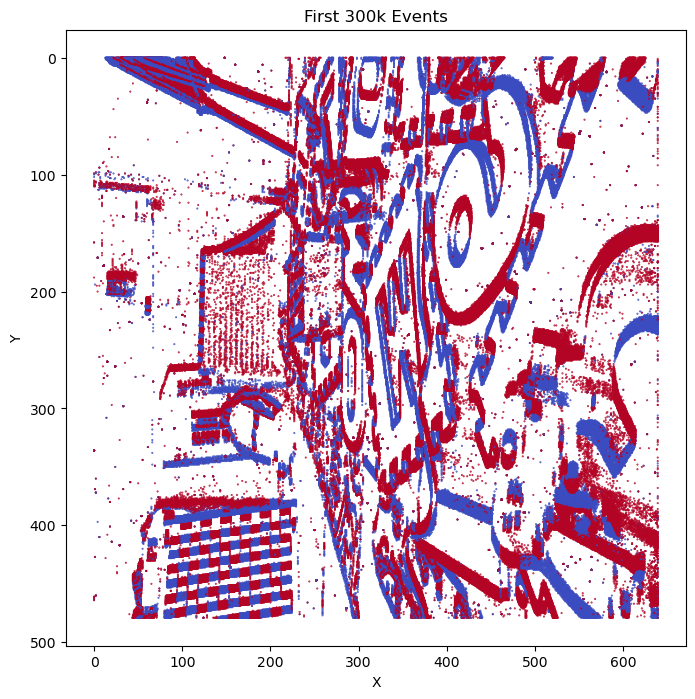

In [23]:
plt.figure(figsize=(8,8))

plt.scatter(
    events_xy[:300000,0],
    events_xy[:300000,1],
    s=0.2,
    c=events_p[:300000],
    cmap="coolwarm"
)

plt.gca().invert_yaxis()

plt.xlabel("X")

plt.ylabel("Y")

plt.title("First 300k Events")

plt.show()

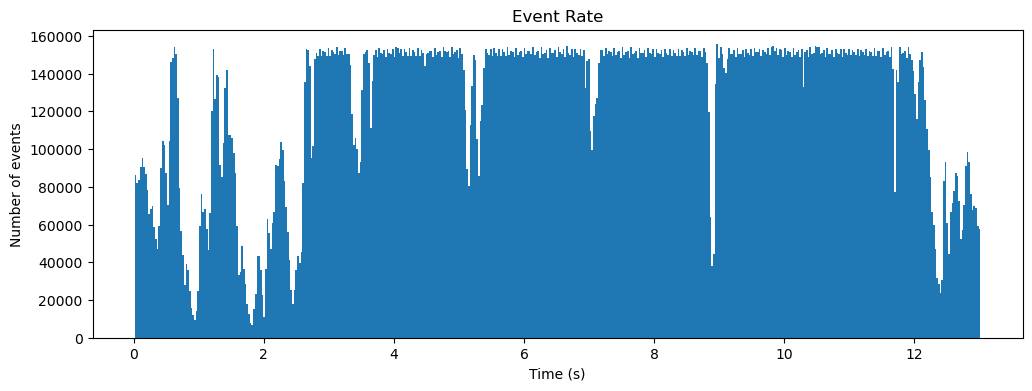

In [24]:
plt.figure(figsize=(12,4))

plt.hist(events_t, bins=500)

plt.xlabel("Time (s)")

plt.ylabel("Number of events")

plt.title("Event Rate")

plt.show()

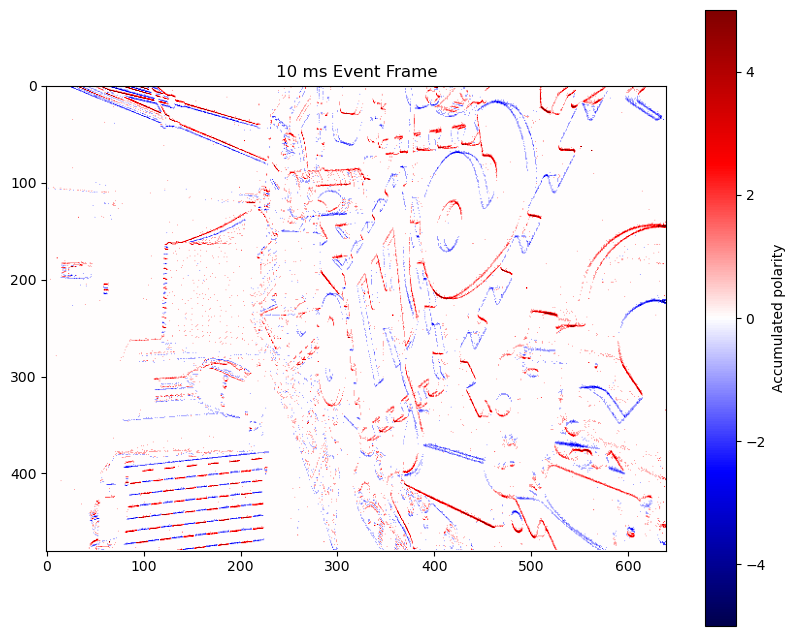

In [25]:
dt = 0.01  # 10 ms

mask = (events_t >= events_t[0]) & (events_t < events_t[0] + dt)

xy = events_xy[mask]
pol = events_p[mask]

H = events_xy[:,1].max() + 1
W = events_xy[:,0].max() + 1

frame = np.zeros((H, W), dtype=np.int16)

for (x, y), p in zip(xy, pol):
    frame[y, x] += 1 if p else -1

plt.figure(figsize=(10, 8))
plt.imshow(frame, cmap="seismic", vmin=-5, vmax=5)
plt.colorbar(label="Accumulated polarity")
plt.title("10 ms Event Frame")
plt.show()